<a href="https://colab.research.google.com/github/justpr09rammer/ML_Self_Study/blob/main/Linear_Regression_From_Scratch_one_feature.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linar Regression With A Single Feature**

Importing important libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D


Creating a simple dataset

In [ ]:
np.random.seed(30)
x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 7.0, 5.0])
noise = np.random.uniform(-10, 10, size=x_train.shape)
y_train = 4.15 * x_train + noise

In a linear model we should find best line y = w * x + b

Text(0.5, 0, 'Size (1000 sqft)')

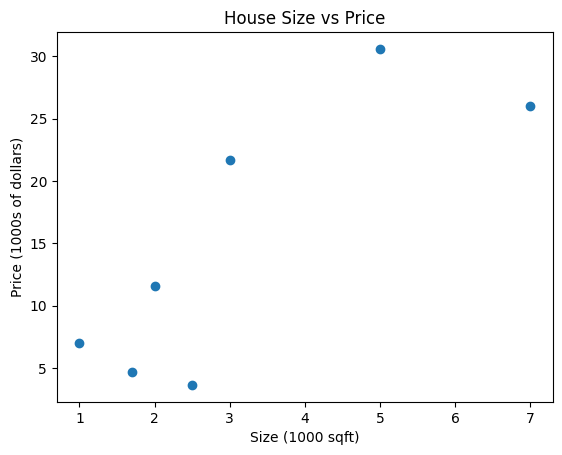

In [ ]:
plt.scatter(x_train, y_train)
plt.title("House Size vs Price")
plt.ylabel('Price (1000s of dollars)')
plt.xlabel('Size (1000 sqft)')

Below we have compute_cost function, which kinda represents how precise the model is. And now, we need to make it more precise, so we need to update w and b in a way that decreases the function. Therefore we will be using partial derivative to decide whether so small changes in w and b increases or decreases the function and how much, basically we are finding the slope at the given w and b, whose negative gives us the direction of steepest descent.

In [ ]:
#function to calculate cost with given w, and b
def compute_cost(x, y, w, b):
  m = x.shape[0]
  total_cost = 0
  for i in range(m):
    f_wb = w * x[i] + b
    cost = (f_wb - y[i]) ** 2
    total_cost += cost
  total_cost /= (2 * m)
  return total_cost

In [ ]:
#creating 3d graph of cost function to see it depends on w and b
w_vals = np.linspace(0, 8, 100)
b_vals = np.linspace(-50, 50, 100)
W, B = np.meshgrid(w_vals, b_vals)
J_vals = np.zeros((w_vals.shape[0], b_vals.shape[0]))
for i in range(w_vals.shape[0]):
  for j in range(b_vals.shape[0]):
    J_vals[i, j] = compute_cost(x_train, y_train, W[i, j], B[i, j])

Cost at w = 6, b = 40 is 990.9082296405612


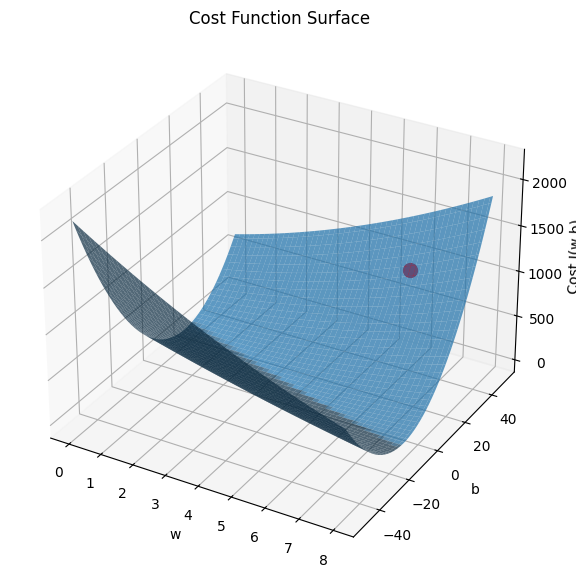

In [ ]:
#to see random selected w and b in the cost fuction
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
w_init = 6
b_init = 40
cost = compute_cost(x_train, y_train, w_init, b_init)
print(f'Cost at w = {w_init}, b = {b_init} is {cost}')
# Plot surface
ax.plot_surface(W, B, J_vals, alpha=0.7)
# Plot the point (w, b, cost)
ax.scatter(w_init, b_init, cost, c='r', marker='o', s=100)

ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_zlabel('Cost J(w,b)')
ax.set_title('Cost Function Surface')

plt.show()

In [ ]:
#now parameter updating part for w and b
def compute_gradient(x, y, w, b):
  m = x.shape[0]
  dj_dw = 0
  dj_db = 0
  for i in range(m):
    f_wb_i = w * x[i] + b
    dj_dw_i = (f_wb_i - y[i]) * x[i]
    dj_db_i = (f_wb_i - y[i])
    dj_db += dj_db_i
    dj_dw += dj_dw_i
  dj_dw /= m
  dj_db /= m
  return dj_dw, dj_db

In [ ]:
# def dj_dw(x, y, w, b):
#   m = x.shape[0]
#   dj_dw = 0
#   for i in range(m):
#     f_wb_i = w * x[i] + b
#     dj_dw_i = (f_wb_i - y[i]) * x[i]
#     dj_dw += dj_dw_i
#   dj_dw /= m
#   return dj_dw

In [ ]:
# def dj_db(x, y, w, b):
#   m = x.shape[0]
#   dj_db = 0
#   for i in range(m):
#     f_wb_i = w * x[i] + b
#     dj_db_i = (f_wb_i - y[i])
#     dj_db += dj_db_i
#   dj_db /= m
#   return dj_db


In [ ]:
#using it in gradient computing
def gradient_descent(x, y, w_initial, b_initial, compute_gradient, cost_function, theta, num_iters):
  w = w_initial
  b = b_initial

  J_history = [] #cost history
  p_history = [] #paramter history
  for i in range(num_iters):
    dj_dw , dj_db = compute_gradient(x, y, w, b)
    w = w - theta * dj_dw
    b = b - theta * dj_db
    J_history.append(cost_function(x, y, w, b))
    p_history.append([w, b])
  return w, b, J_history, p_history

Testing the model

In [ ]:
w_init = 0
b_init = 0
J_history = []
p_history= []
w_final, b_final, J_history, p_history = gradient_descent(x_train, y_train, w_init, b_init, compute_gradient, compute_cost, theta = 0.001, num_iters=10000)
print(f" (w, b) found : ({w_final:8.4f},{b_final:8.4f})")

 (w, b) found : (  4.2565,  1.5165)


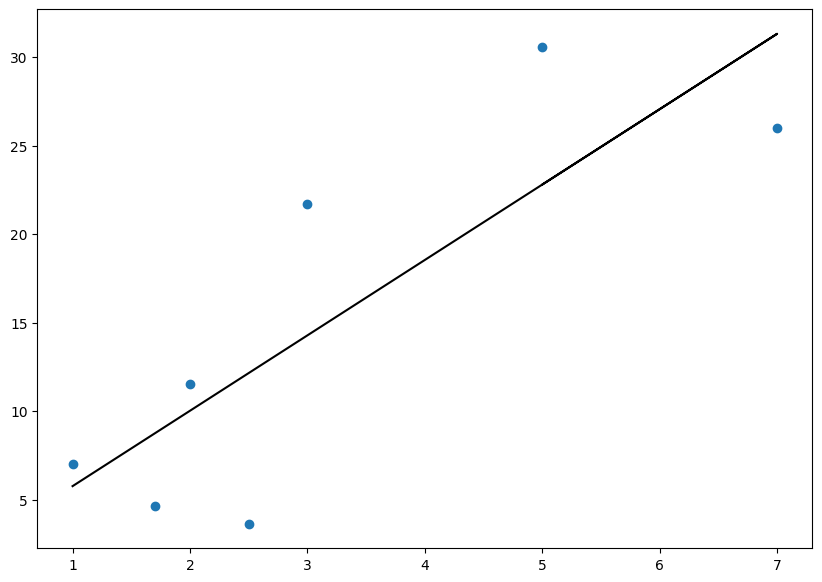

In [ ]:
y_predicted = w_final * x_train + b_final
plt.figure(figsize=(10, 7))
plt.plot(x_train, y_predicted, c = 'black')
plt.scatter(x_train, y_train)


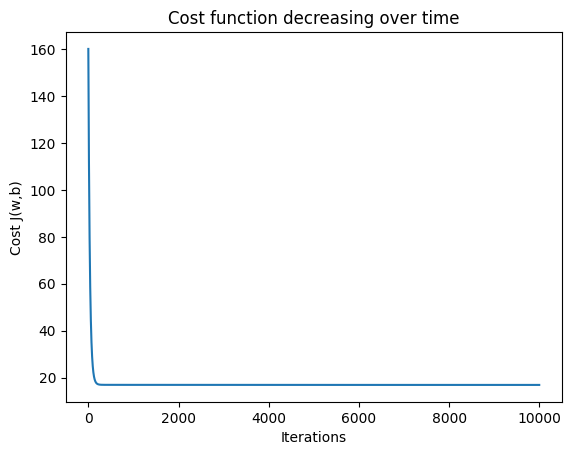

In [ ]:
plt.plot(J_history)
plt.xlabel("Iterations")
plt.ylabel("Cost J(w,b)")
plt.title("Cost function decreasing over time")

plt.show()

Cost at w_final = 4.256531010077468, b_final = 1.5164573885144998 is 16.93092145906325


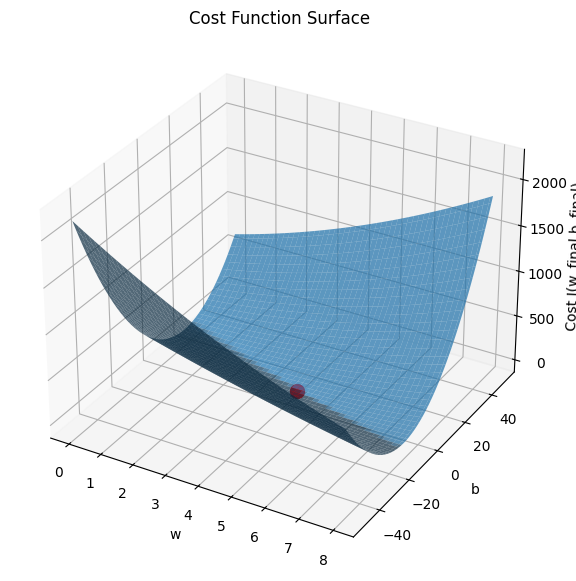

In [ ]:
#to see w_final and b_final in the cost fuction
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
cost = compute_cost(x_train, y_train, w_final, b_final)
print(f'Cost at w_final = {w_final}, b_final = {b_final} is {cost}')
# Plot surface
ax.plot_surface(W, B, J_vals, alpha=0.7)
# Plot the point (w, b, cost)
ax.scatter(w_final, b_final, cost, c='r', marker='o', s=100)

ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_zlabel('Cost J(w_final,b_final)')
ax.set_title('Cost Function Surface')

plt.show()

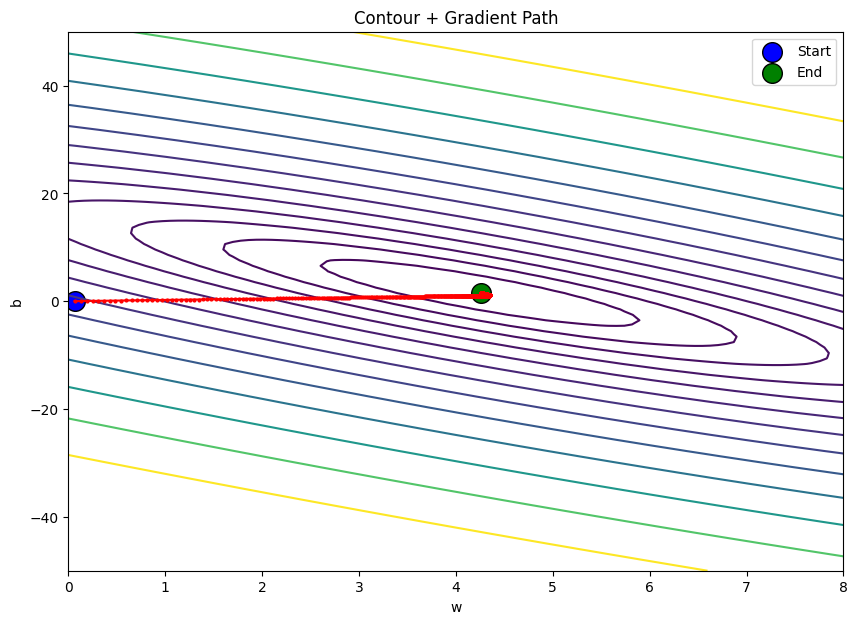

In [ ]:
#to see better how cost changes over time, here is the contour plot
w_hist = [p[0] for p in p_history]
b_hist = [p[1] for p in p_history]
plt.figure(figsize=(10, 7))
plt.contour(W, B, J_vals, levels=np.logspace(-1, 3, 30))
plt.plot(w_hist, b_hist, 'r-o', markersize=2)

plt.scatter(w_hist[0], b_hist[0],
            c='blue', label='Start',
            marker='o', s=200, edgecolors='black')

plt.scatter(w_final, b_final,
            c='green', label='End',
            marker='o', s=200, edgecolors='black')
plt.xlabel('w')
plt.ylabel('b')
plt.title("Contour + Gradient Path")
plt.legend()